In [2]:
# -*- coding: utf-8 -*-
"""
试卷 C - 基于神经网络的手写数字识别模型训练与测试
要求：MNIST 数据加载与预处理，构建全连接神经网络，训练并保存模型，测试并可视化结果
"""

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import load_model
import os

In [ ]:
pip uninstall tensorflow -y

In [1]:
pip install tensorflow==2.13.0

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for tensorflow==2.13.0 from https://files.pythonhosted.org/packages/9e/b8/ed5f794359d05cd0bffb894c6418da87b93016ee17b669d55c45d1bd5d5b/tensorflow-2.13.0-cp311-cp311-win_amd64.whl.metadata
  Using cached tensorflow-2.13.0-cp311-cp311-win_amd64.whl.metadata (2.6 kB)
  Obtaining dependency information for tensorflow-intel==2.13.0 from https://files.pythonhosted.org/packages/2f/2f/3c84f675931ce3bcbc7e23acbba1e5d7f05ce769adab48322de57a9f5928/tensorflow_intel-2.13.0-cp311-cp311-win_amd64.whl.metadata
  Using cached tensorflow_intel-2.13.0-cp311-cp311-win_amd64.whl.metadata (4.1 kB)
Using cached tensorflow-2.13.0-cp311-cp311-win_amd64.whl (1.9 kB)
Using cached tensorflow_intel-2.13.0-cp311-cp311-win_amd64.whl (276.6 MB)
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [3]:
# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [4]:
# ==================== 1. 数据准备 ====================
print("加载 MNIST 数据集...")
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(f"训练集样本数: {x_train.shape[0]}, 图片尺寸: {x_train.shape[1]}x{x_train.shape[2]}")
print(f"测试集样本数: {x_test.shape[0]}")

加载 MNIST 数据集...
11490434/11490434 [==============================] - 5s 0us/step
训练集样本数: 60000, 图片尺寸: 28x28
测试集样本数: 10000


In [5]:
# 数据预处理：归一化到 [0,1]，并 reshape 为向量
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train_vec = x_train.reshape(x_train.shape[0], -1)  # 展平为 784 维向量
x_test_vec = x_test.reshape(x_test.shape[0], -1)

In [6]:
# 标签 one-hot 编码
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)
print("数据预处理完成。")

数据预处理完成。


In [7]:
# ==================== 2. 构建与训练神经网络模型 ====================
model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 10)                650       
                                                                 
Total params: 109386 (427.29 KB)
Trainable params: 109386 (427.29 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


In [8]:
# 训练模型
history = model.fit(x_train_vec, y_train_cat,
                    validation_data=(x_test_vec, y_test_cat),
                    epochs=10,
                    batch_size=128,
                    verbose=1)

Epoch 1/10
469/469 [==============================] - 1s 2ms/step - loss: 0.3421 - accuracy: 0.9004 - val_loss: 0.1606 - val_accuracy: 0.9526
Epoch 2/10
469/469 [==============================] - 1s 2ms/step - loss: 0.1385 - accuracy: 0.9603 - val_loss: 0.1144 - val_accuracy: 0.9638
Epoch 3/10
469/469 [==============================] - 1s 2ms/step - loss: 0.0943 - accuracy: 0.9719 - val_loss: 0.0930 - val_accuracy: 0.9711
Epoch 4/10
469/469 [==============================] - 1s 2ms/step - loss: 0.0711 - accuracy: 0.9788 - val_loss: 0.0884 - val_accuracy: 0.9729
Epoch 5/10
469/469 [==============================] - 1s 2ms/step - loss: 0.0555 - accuracy: 0.9829 - val_loss: 0.0782 - val_accuracy: 0.9760
Epoch 6/10
469/469 [==============================] - 1s 2ms/step - loss: 0.0440 - accuracy: 0.9867 - val_loss: 0.0773 - val_accuracy: 0.9776
Epoch 7/10
469/469 [==============================] - 1s 2ms/step - loss: 0.0341 - accuracy: 0.9899 - val_loss: 0.0774 - val_accuracy: 0.9766
Epoch 

In [9]:
# 保存模型
model.save('mnist_model.h5')
print("模型已保存为 mnist_model.h5")

模型已保存为 mnist_model.h5


C:\Users\user\AppData\Roaming\Python\Python311\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


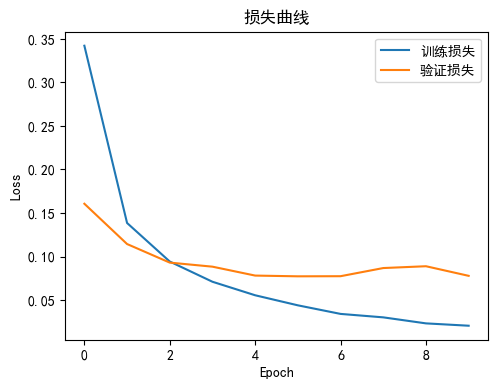

In [10]:
# 绘制训练曲线
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='训练损失')
plt.plot(history.history['val_loss'], label='验证损失')
plt.title('损失曲线')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

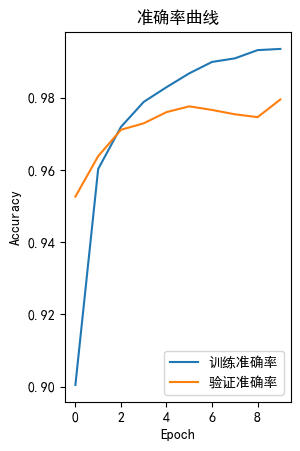

In [11]:
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='训练准确率')
plt.plot(history.history['val_accuracy'], label='验证准确率')
plt.title('准确率曲线')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [12]:
# ==================== 3. 模型测试与结果展示 ====================
# 加载模型（演示从文件加载）
if os.path.exists('mnist_model.h5'):
    model = load_model('mnist_model.h5')
    print("模型加载成功。")

模型加载成功。


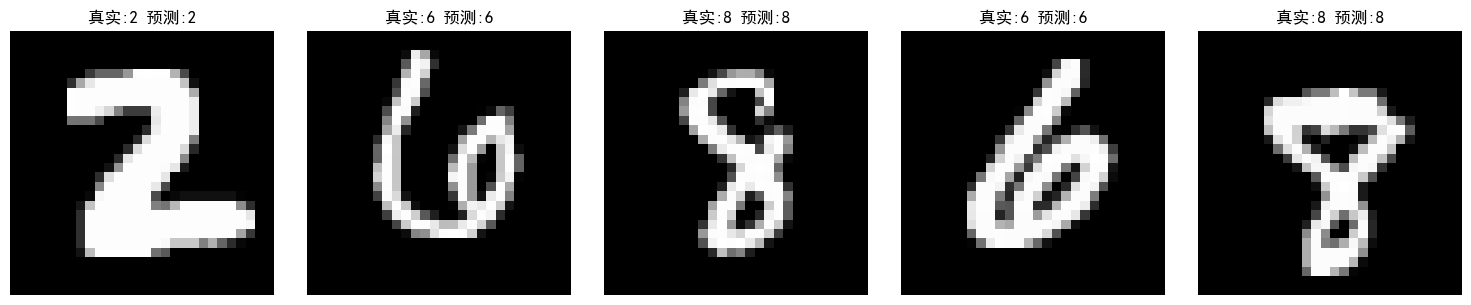

In [13]:
# 随机选择5张测试图片
indices = np.random.choice(len(x_test), 5, replace=False)
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, idx in enumerate(indices):
    img = x_test[idx].reshape(28, 28)
    pred = model.predict(x_test_vec[idx].reshape(1, 784), verbose=0)
    pred_label = np.argmax(pred)
    true_label = y_test[idx]
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'真实:{true_label} 预测:{pred_label}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [14]:
# 展示单张图片的预测概率分布
sample_idx = indices[0]
sample_img = x_test[sample_idx].reshape(28, 28)
sample_pred = model.predict(x_test_vec[sample_idx].reshape(1, 784), verbose=0)[0]

(-0.5, 27.5, 27.5, -0.5)

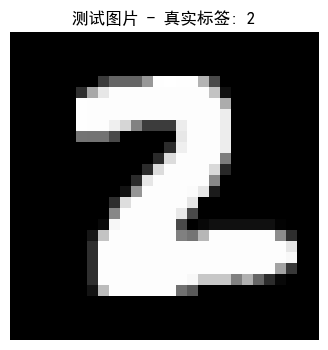

In [15]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample_img, cmap='gray')
plt.title(f'测试图片 - 真实标签: {y_test[sample_idx]}')
plt.axis('off')

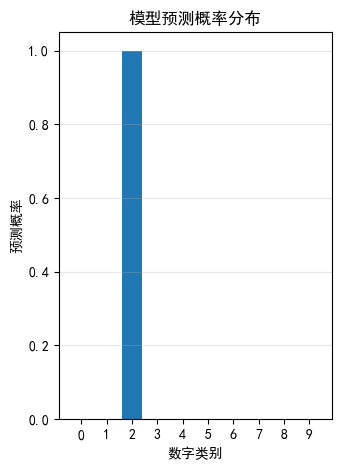

测试完成。


In [16]:
plt.subplot(1, 2, 2)
plt.bar(range(10), sample_pred)
plt.xlabel('数字类别')
plt.ylabel('预测概率')
plt.title('模型预测概率分布')
plt.xticks(range(10))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("测试完成。")